# 🧠 Introduction to CNNs for Image Classification

Until now, you've learned how to apply machine learning to structured datasets (like predicting prices or classifying data based on features). But how can we teach a machine to recognize images, like telling the difference between a **headlight**, a **bumper**, or a **wheel**?

That’s where **Convolutional Neural Networks (CNNs)** come in. CNNs are the **go-to architecture** in deep learning when it comes to visual understanding.

---

## 🧩 The Challenge with Image Data

Images are not like tabular data. A single color image of size 128×128 has **49,152 features** (128 × 128 × 3), which:
- Makes them **high-dimensional**
- Contains **spatial relationships** (e.g. a tire is round, and a headlight has glassy edges)
- Makes flattening them (as we did in ML) **lose important context**

Traditional ML methods treat all pixels independently. But CNNs understand **space** — they "look" at nearby pixels together, like how our eyes and brains work.

---

## 👁️ What is a CNN?

CNNs (Convolutional Neural Networks) are **neural networks designed specifically for images**. They learn patterns from raw pixel data through **filters** that scan the image.


![How a CNN Works](./images_gifs/cnnimage.png)


### Think of CNNs as layers of virtual eyes:
1. **Early layers** detect **edges**, **lines**, and **color patterns**
2. **Middle layers** detect **shapes**, **textures**, or **symmetry**
3. **Later layers** detect **parts**, **objects**, or **combinations**

All this happens without us manually designing the features. CNNs learn them during training.

---

![Digits](images_gifs/cnndigits.gif)

### 💡 How a CNN Works (Layer Ideas)

**Convolution Layer**
➤ Learns small visual patterns (like edges, curves, textures)
➤ Uses filters that slide over the image

**Activation (ReLU)**
➤ Keeps only useful signals (sets negatives to 0)
➤ Adds non-linearity so it can learn complex patterns

**Pooling Layer**
➤ Shrinks the feature maps (like zooming out)
➤ Keeps the strongest features (e.g., max pooling)

**More Conv + Pool Layers**
➤ Deeper layers learn higher-level parts (like car lights, tires)
➤ Each layer builds on the previous ones

**Flatten Layer**
➤ Turns 2D feature maps into a 1D vector
➤ Prepares data for the final decision

**Fully Connected (Dense) Layers**
➤ Combine all features to predict the class
➤ Similar to layers in traditional neural networks

**Softmax Output**
➤ Outputs class probabilities
➤ The highest value is the model’s prediction

![convs](images_gifs/convolutions.gif)

### Your Challenge:

In this notebook, we’ll train a CNN to recognize different **car parts** from images. These might include parts like:
- air compressor
- battery
- brake caliper
- coil spring
- oil pan and so on

**Total of 50 car parts**


You don’t need to **tell** the model what a headlight looks like — it will **learn** the patterns by itself from labeled training images.


By the end of this notebook, you'll be able to:

✅ Load and preprocess image data  
✅ Build your own CNN using TensorFlow/Keras  
✅ Train and evaluate the model  
✅ Visualize performance with graphs and confusion matrices  
✅ Experiment with changes and improve accuracy  


## 🖼️ Let's Look at Some Examples!

Before we start coding, here are some sample images from our dataset (randomly picked from different classes):

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
!cp -r /content/drive/MyDrive/Dataset_Piese /content/Dataset_Piese_Local

- The cells above are only for the Collab setup

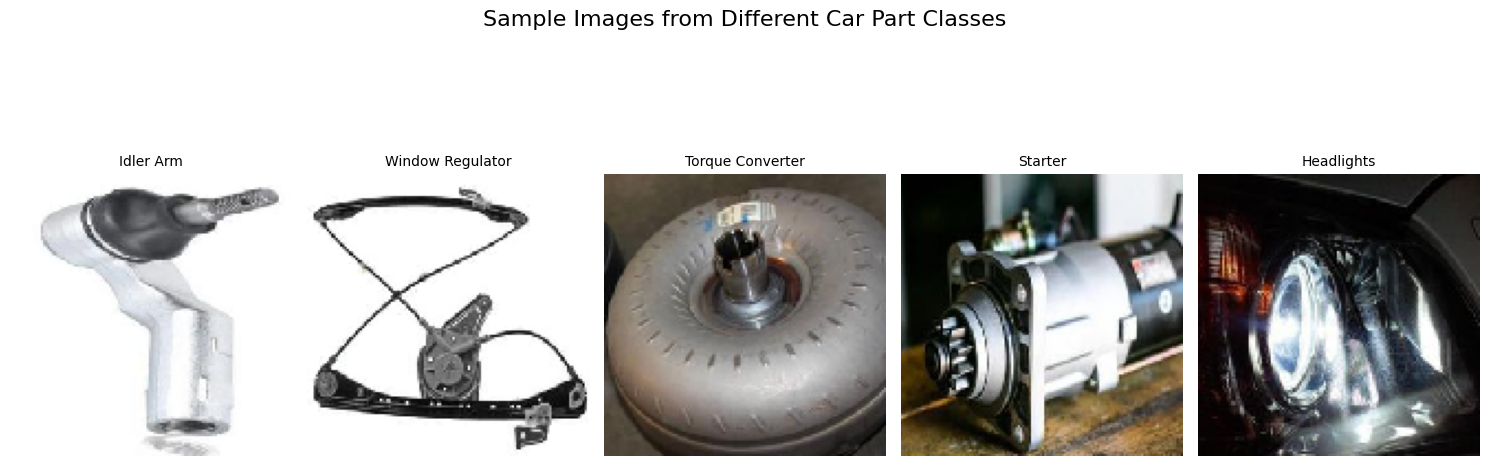

In [16]:
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image
from PIL import Image
# this cell is only runnable on collab
dataset_path = '/content/Dataset_Piese_Local/train'

class_dirs = [d for d in os.listdir(dataset_path)
              if os.path.isdir(os.path.join(dataset_path, d)) and not d.startswith('.')]

sampled_classes = random.sample(class_dirs, min(5, len(class_dirs)))

plt.figure(figsize=(15, 6))

for i, class_name in enumerate(sampled_classes):
    class_folder = os.path.join(dataset_path, class_name)

    valid_extensions = ['.jpg', '.jpeg', '.png']
    images_in_class = [f for f in os.listdir(class_folder)
                       if f.lower().endswith(tuple(valid_extensions)) and not f.startswith('.')]

    if not images_in_class:
        continue

    sample_image = random.choice(images_in_class)
    img_path = os.path.join(class_folder, sample_image)

    img = image.load_img(img_path, target_size=(128, 128))
    ax = plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(class_name.title(), fontsize=10)
    plt.axis("off")

plt.suptitle("Sample Images from Different Car Part Classes", fontsize=16)
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd

#Load dataset
df = pd.read_csv('./dataset/car parts.csv')
df.head(20)

,class index,filepaths,labels,data set
0,0,train/AIR COMPRESSOR/001.jpg,AIR COMPRESSOR,train
1,0,train/AIR COMPRESSOR/002.jpg,AIR COMPRESSOR,train
2,0,train/AIR COMPRESSOR/003.jpg,AIR COMPRESSOR,train
3,0,train/AIR COMPRESSOR/004.jpg,AIR COMPRESSOR,train
4,0,train/AIR COMPRESSOR/005.jpg,AIR COMPRESSOR,train
5,0,train/AIR COMPRESSOR/006.jpg,AIR COMPRESSOR,train
6,0,train/AIR COMPRESSOR/007.jpg,AIR COMPRESSOR,train
7,0,train/AIR COMPRESSOR/008.jpg,AIR COMPRESSOR,train
8,0,train/AIR COMPRESSOR/009.jpg,AIR COMPRESSOR,train
9,0,train/AIR COMPRESSOR/010.jpg,AIR COMPRESSOR,train


In [12]:
label_counts = df['labels'].value_counts().sort_values(ascending=False)
label_counts

labels
IGNITION COIL           210
IDLER ARM               208
STARTER                 205
CARBERATOR              202
ALTERNATOR              200
OVERFLOW TANK           199
RADIO                   199
SHIFT KNOB              199
BRAKE PAD               198
ENGINE BLOCK            198
FUEL INJECTOR           198
OIL PAN                 197
OIL PRESSURE SENSOR     197
TORQUE CONVERTER        197
GAS CAP                 196
SIDE MIRROR             196
AIR COMPRESSOR          195
SPOILER                 195
CYLINDER HEAD           194
OXYGEN SENSOR           192
PRESSURE PLATE          192
THERMOSTAT              192
CLUTCH PLATE            191
CRANKSHAFT              190
INSTRUMENT CLUSTER      190
RIM                     189
WINDOW REGULATOR        189
VACUUM BRAKE BOOSTER    188
BATTERY                 187
BRAKE ROTOR             186
WATER PUMP              186
RADIATOR HOSE           185
VALVE LIFTER            185
BRAKE CALIPER           184
LOWER CONTROL ARM       179
OIL FILTER   

#### TODO: Research about data augmentation and what to do in case of an unbalanced dataset
##### At the end of the notebook, you can apply these techniques and train another CNN and compare results
- Short explanation: data augmentation is a technique used to increase the diversity of your training data without actually collecting new data. It involves applying random transformations such as rotations, flips, zooms, and shifts to the existing images, which helps the model generalize better and reduces overfitting.

## 1. Load & Preprocess the data

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 8))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title("Distribution of Labels in the Dataset")
plt.xlabel("Labels")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

total_labels = len(label_counts)
max_val = label_counts.max()
max_label = label_counts.idxmax()
min_val = label_counts.min()
min_label = label_counts.idxmin()
print(f"Total labels: {total_labels}")
print(f"Max val: {max_val} for label: {max_label}")
print(f"Min val: {min_val} for label: {min_label}")


- As we can see form the diagram and from the tabel with the classes , the dataset is not really imbalanced.
- In some classes we have more "objects" than in the others but the difference is not that significant.

# OBS : THE CODE BELOW IS RUNNABLE ONLY ON COLLAB

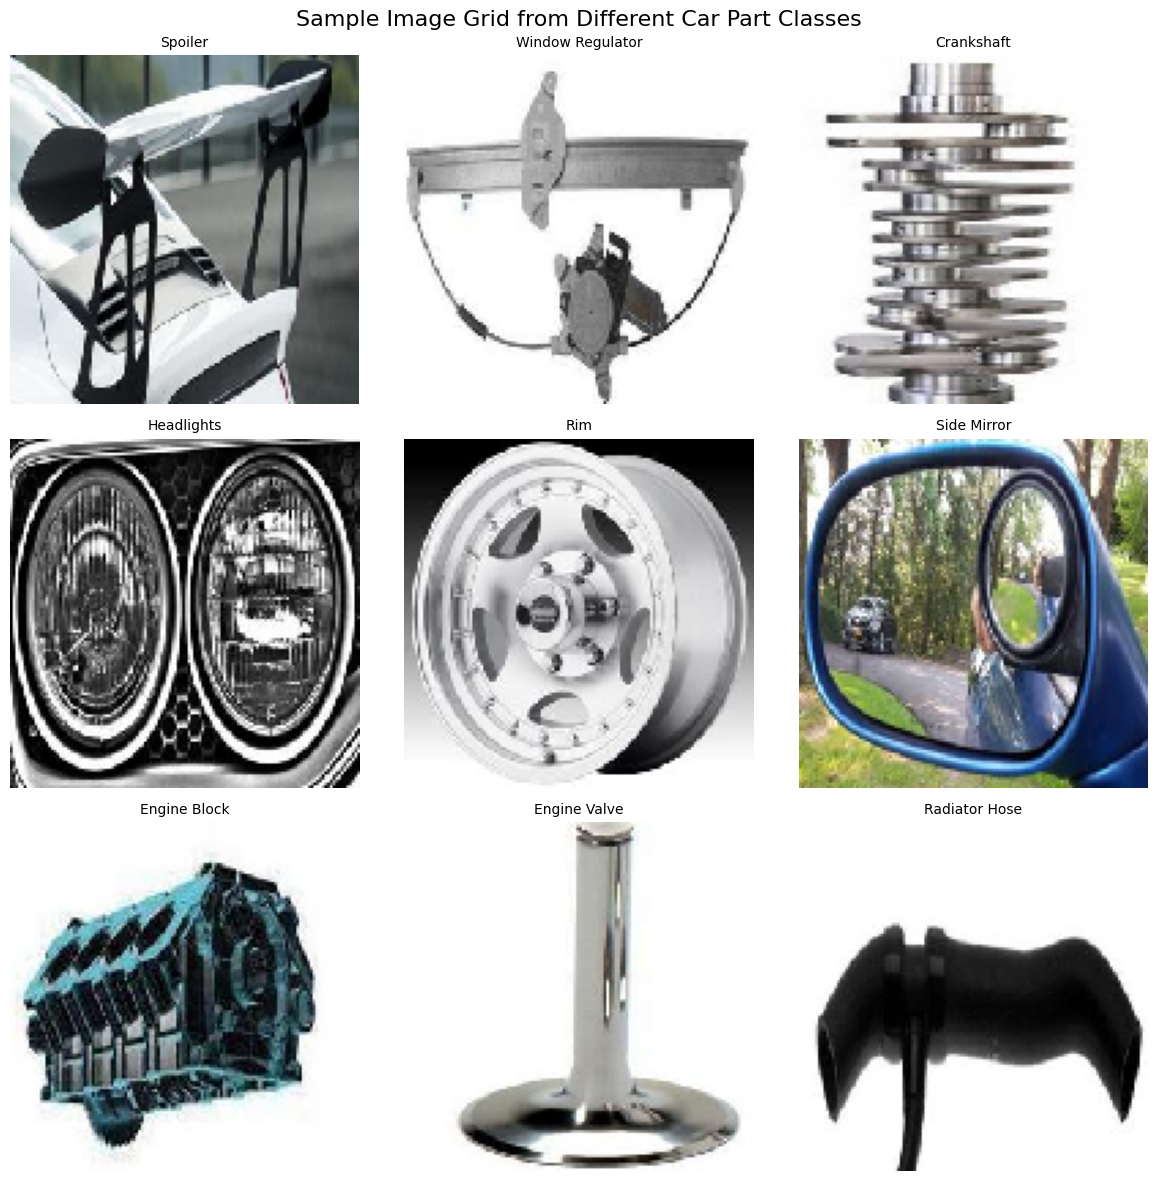

In [20]:
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image
from PIL import Image

dataset_path = '/content/Dataset_Piese_Local/train'

class_dirs = [d for d in os.listdir(dataset_path)
              if os.path.isdir(os.path.join(dataset_path, d)) and not d.startswith('.')]

sampled_classes = random.sample(class_dirs, min(9, len(class_dirs)))

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes=axes.flatten()

for i, class_name in enumerate(sampled_classes):
    class_folder = os.path.join(dataset_path, class_name)

    valid_extensions = ['.jpg', '.jpeg', '.png']
    images_in_class = [f for f in os.listdir(class_folder)
                       if f.lower().endswith(tuple(valid_extensions)) and not f.startswith('.')]

    if not images_in_class:
        continue

    sample_image = random.choice(images_in_class)
    img_path = os.path.join(class_folder, sample_image)

    img = image.load_img(img_path, target_size=(128, 128))
    axes[i].imshow(img)
    axes[i].set_title(class_name.title(), fontsize=10)
    axes[i].axis("off")

plt.suptitle("Sample Image Grid from Different Car Part Classes", fontsize=16)
plt.tight_layout()
plt.show()


## 2. Image loading pipeline & Data Augumentation

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

train_dir='/content/Dataset_Piese_Local/train'
valid_dir='/content/Dataset_Piese_Local/valid'
test_dir='/content/Dataset_Piese_Local/test'

IMG_SIZE=(128, 128)
BATCH_SIZE=32

datagen_test_val=ImageDataGenerator(rescale=1./255)
datagen_train=ImageDataGenerator(rescale=1./255,rotation_range=20,width_shift_range=0.1,height_shift_range=0.1,zoom_range=0.15,horizontal_flip=True,fill_mode='nearest')

train_generator=datagen_train.flow_from_directory(train_dir,target_size=IMG_SIZE,batch_size=BATCH_SIZE,class_mode='categorical')

valid_generator=datagen_test_val.flow_from_directory(valid_dir,target_size=IMG_SIZE,batch_size=BATCH_SIZE,  class_mode='categorical', shuffle=False) #shuffle false because when we test the set as it is not shuffled

test_generator=datagen_test_val.flow_from_directory(test_dir,target_size=IMG_SIZE,batch_size=BATCH_SIZE, class_mode='categorical',shuffle=False)


Found 8739 images belonging to 50 classes.
Found 250 images belonging to 50 classes.
Found 250 images belonging to 50 classes.


- The purpose of this data pipeline is to resize every image to a standard standard resolution (128x128), normalize pixel values to a [0, 1] range, and define data batches for efficient model training and evaluation.
- The rescaling process transforms the original pixel values (0-255) into smaller numbers. This ensures numerical stability and helps the neural network converge faster during optimization.
- The generators for the validation and test sets apply only rescaling. This ensures the model is evaluated on strictly unmodified, real-world data.
- The generator for the training set includes data augmentation because the dataset is relatively small and slightly imbalanced. These transformations are applied dynamically (on-the-fly) to each batch in memory before they are fed to the model. This exposes the network to the car parts in various physical orientations, preventing overfitting and helping it learn generalized features.

## 2.1 Batch shape

In [22]:
images_batch, labels_batch=next(train_generator)

print("Image batch shape: ", images_batch.shape)
print("Label batch shape: ", labels_batch.shape)

Image batch shape:  (32, 128, 128, 3)
Label batch shape:  (32, 50)


- As we can see every image batch has the config like this  (32, 128, 128, 3) where:
  - 32 is the number of images that goes into the model at once
  - 128 rep the image size (128x128)
  - 3 represent the color channels (RGB)
    - Every color channel represents a matrix , the image itself it's not only a matrix like a black and white one, but actually 3 matrices stacked on top of each other (a 3D tensor).

## 2.3 Pixel range

In [23]:
min_pixel=np.min(images_batch)
max_pixel=np.max(images_batch)

print("min_pixel: ", min_pixel)
print("max_pixel: ", max_pixel)

min_pixel:  0.0
max_pixel:  1.0


## 3. Build the CNN model

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D,MaxPooling2D,Flatten

model= Sequential([
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(units=128, activation='relu'),
    Dense(units=50, activation='softmax'),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,311,090 (12.63 MB)

 Trainable params: 3,311,090 (12.63 MB)

 Non-trainable params: 0 (0.00 B)

- As we can see from the summary, the model has a total of 3,311,090 trainable parameters, which represents the total number of weights the network needs to adjust during the learning process.
- The spatial dimensions of the image are progressively cut in half after every MaxPooling2D layer, dropping from an initial 126x126 grid down to a highly compressed 14x14 grid.
- While the image size gets smaller, the depth of the data increases at every Conv2D block (scaling from 32, to 64, and finally to 128 filters), allowing the network to extract increasingly complex features at each step.
- The Flatten layer acts as a bridge for the classifier, converting the final 3D tensor (14x14x128) into a single 1D array of 25,088 values (14 * 14 * 128).
- The first Dense layer contains the vast majority of the model's parameters (over 3.2 million). This massive spike happens because it is a fully connected layer, meaning every single one of its 128 neurons connects to all 25,088 input values.
- The final output layer has a shape of (None, 50), which perfectly aligns with our dataset of 50 distinct car part classes.

## 4. Compile The Model

In [25]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

## 5. Train The Model

In [26]:
history=model.fit(train_generator,epochs=20,validation_data=valid_generator)

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 52s 176ms/step - accuracy: 0.0843 - loss: 3.6134 - val_accuracy: 0.2440 - val_loss: 2.9528
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 44s 162ms/step - accuracy: 0.2574 - loss: 2.8420 - val_accuracy: 0.3600 - val_loss: 2.5384
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 44s 161ms/step - accuracy: 0.3516 - loss: 2.4579 - val_accuracy: 0.4680 - val_loss: 2.1418
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 44s 161ms/step - accuracy: 0.4090 - loss: 2.1720 - val_accuracy: 0.4880 - val_loss: 2.0918
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 44s 160ms/step - accuracy: 0.4602 - loss: 1.9652 - val_accuracy: 0.5320 - val_loss: 1.8922
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 44s 161ms/step - accuracy: 0.5045 - loss: 1.8143 - val_accuracy: 0.5840 - val_loss: 1.7478
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 44s 160ms/step - accuracy: 0.5283 - loss: 1.6939 - val_accuracy: 0.6040 - val_loss: 1.6847
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 45s 162ms/step - accuracy: 0.5519 - loss: 1

## 6. Evaluate and visualise the results: Part 1.

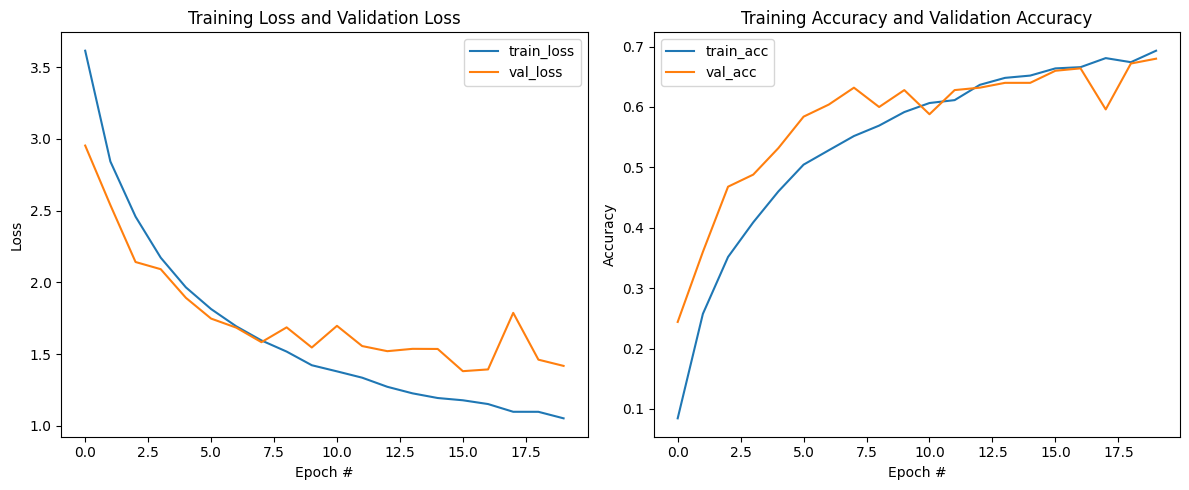

In [27]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Training Loss and Validation Loss")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("Training Accuracy and Validation Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


#### Is the model overfitting or underfitting?

- The training curves indicate that the model learns effectively throughout the training process. Both the training and validation loss decrease significantly during the first epochs, while training and validation accuracy steadily increase.
- The model shows slight overfitting rather than underfitting. After approximately epoch 8–10, the training loss continues to decrease, whereas the validation loss begins to fluctuate instead of consistently improving. However, the gap between training accuracy (~69%) and validation accuracy (~68%) remains very small, indicating that the model still generalizes reasonably well.
- The fluctuations in the validation metrics are likely caused by the small dataset size, which makes validation performance more sensitive to variations between epochs.
#### At which epoch is validation performance best?
- The best validation performance is achieved around epoch 19 (the final epoch), where the validation accuracy reaches approximately 68% while the validation loss is close to its minimum.
- Although the validation loss fluctuates during training, the final epoch provides the highest validation accuracy with good overall generalization.
#### Techniques to Prevent Overfitting
1. Data Augmentation(already applied)
   - Artificially increases the diversity of the training data by applying random transformations such as rotation, translation, zoom, and horizontal flipping.
   - This helps the model become more robust and improves generalization, especially when training on small datasets.
2. Dropout
   - Randomly disables a fraction of neurons during training, forcing the network to learn more robust feature representations instead of relying on specific neurons.
   - Common dropout rates range between 0.2 and 0.5.
3. Early Stopping
   - Stops training when the validation loss no longer improves for several consecutive epochs.
   - This prevents the model from continuing to fit the training data after reaching its optimal validation performance.
4. Batch Normalization
   - Normalizes intermediate activations during training, leading to more stable gradients and faster convergence.
   - It can also provide a mild regularization effect that improves generalization.
5. L2 Regularization (Weight Decay)
   - Adds a penalty to large model weights during optimization.
   - This encourages simpler models that are less likely to overfit the training data.

In [28]:
model.save('/content/drive/MyDrive/Dataset_Piese/car_parts_model.keras')


import pandas as pd
history_df = pd.DataFrame(history.history)
history_df.to_csv('/content/drive/MyDrive/Dataset_Piese/training_history.csv', index=False)

- This cell is from Collab to save the model and the dictionary in drive

### Your task:

#### Quick CNN Workflow for Image Classification

1. **Load & preprocess data**  
   - Resize images and normalize pixel values (e.g., scale pixels to [0,1])  
   - Prepare labels for classification  

2. **Create training and validation data generators**  
   - Use `ImageDataGenerator` or custom loaders to batch and augment data  (If you want to, or skip this part for now)

3. **Build the CNN model**  
   - Stack convolutional layers (Conv2D + activation function) and pooling layers
   - Flatten and add dense layers for final classification  
   - Make sure to use the right activation function for the last Dense layer.

4. **Compile the model**  
   - Use suitable loss function nd an optimizer like Adam  

5. **Train the model**  
   - Fit the model on training data and validate on validation data over multiple epochs  
   - Find the right number of batches/epochs for your data

6. **Evaluate and visualize results**  
   - Plot Accuracy & Loss Curves for training/validation
   - Learn about overfitting/underfitting and how to prevent these situations
   - Generate confusion matrix and classification report, based on metrics like accuracy

7. **Explore**
   - Use a pretrained available model
   - Change the architecture
   - Integrate the model into a small GUI and make it more interactive
   - Test with images from the internet, and see how well it performs
